# Binance → Aster/Lighter lead/lag

**Question.** At our collector, when the Binance BTC-perp mid moves by at least $X$ bps, does the
Aster or Lighter mid follow? By how much, after how long, and does a **taker round trip on the
lag venue** (enter at $t_0+L$, exit at $t_0+L+h$) beat two taker fees?

This is the measurement behind a possible `LeadLagStrategy` with a time exit at horizon $h$.
It reports conditional statistics, **not simulated PnL**: no queue position, partial fills,
inventory limits or overlapping positions.

Rules:
- Time is Local Receive Time on the shared capture clock. The lead is measured *at our VPS*,
  including each venue's feed path. That is the right frame for trading from here, not
  exchange-level causality.
- Book state at time $t$ is the last accepted snapshot at or before $t$. Order Book outages
  remove the state until the next snapshot, and quotes older than `STALE_NS` are unusable.
- Parameters are chosen on **train** and reported once on **validation**. The **test** split is
  never loaded.
- Binance is signal-only (ADR 0010): every round trip is on Aster or Lighter.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import polars as pl

PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "backend").is_dir())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from experiments.analysis.lead_lag import (
    binance_move_events, cross_correlation, first_lag_move, responses, round_trip_edge, top_of_book,
)
from experiments.simulator.splits import chronological_splits

DATASET = PROJECT_ROOT / "experiments/data/parquet/6b556515-5156-4181-8a6f-7403fa9078fe"
MS = 1_000_000
STALE_NS = 1_000 * MS
WINDOW_NS = 200 * MS           # two Binance snapshots at its ~100 ms cadence
COOLDOWN_NS = 2_000 * MS       # = longest horizon, so event responses never overlap
THRESHOLDS_BPS = [2.0, 5.0, 10.0]
HORIZONS_NS = [h * MS for h in (10, 25, 50, 100, 250, 500, 1000, 2000)]
LATENCIES_NS = [l * MS for l in (0, 25, 50, 100)]
FEES_BPS = [0.0, 2.5, 5.0]     # placeholders until verified venue fee tiers exist
LAG_VENUES = ["aster", "lighter"]

train, validation, test = chronological_splits(DATASET)
SPLITS = {"train": train, "validation": validation}
assert all(s.sequence_end is not None and s.sequence_end <= test.sequence_start for s in SPLITS.values())
print(train, validation, sep="\n")

Split(name='train', sequence_start=1, sequence_end=2403822)
Split(name='validation', sequence_start=2403822, sequence_end=3514231)


## 1. Data checks: quote cadence and spread

In [2]:
tob = {name: top_of_book(DATASET, s.sequence_start, s.sequence_end) for name, s in SPLITS.items()}
venue = lambda split, v: tob[split].filter(pl.col("venue") == v)

pl.concat([
    tob[name].sort("venue", "t").with_columns(pl.col("t").diff().over("venue").alias("dt"))
    .group_by("venue").agg(
        pl.lit(name).alias("split"),
        pl.len().alias("rows"),
        pl.col("mid").null_count().alias("outage_markers"),
        (pl.col("dt").median() / MS).alias("update_ms_p50"),
        (pl.col("dt").quantile(0.99) / MS).alias("update_ms_p99"),
        ((pl.col("ask") - pl.col("bid")) / pl.col("mid") * 1e4).median().alias("spread_bps_p50"),
        ((pl.col("ask") - pl.col("bid")) / pl.col("mid") * 1e4).quantile(0.9).alias("spread_bps_p90"),
    )
    for name in SPLITS
]).sort("split", "venue")

venue,split,rows,outage_markers,update_ms_p50,update_ms_p99,spread_bps_p50,spread_bps_p90
str,str,u32,u32,f64,f64,f64,f64
"""aster""","""train""",425168,0,106.892146,195.702177,0.011816,0.011859
"""binance""","""train""",439364,0,102.106626,335.781826,0.011815,0.011854
"""lighter""","""train""",761756,1,51.053424,252.813366,0.011883,0.556571
"""aster""","""validation""",146983,0,105.758151,161.995575,0.011967,0.012015
"""binance""","""validation""",158970,0,102.041137,173.038672,0.011957,0.011999
"""lighter""","""validation""",304429,1,50.395769,151.517086,0.071313,0.736699


Binance arrives as a top-10 partial-depth snapshot roughly every **100 ms**, Aster every ~100 ms
and Lighter every ~50 ms. So no lead shorter than about one Binance interval can be resolved
from books alone. Binance aggregate trades arrive tick by tick and could detect moves sooner.
They are not used here.

### Data-quality check: Binance book vs Binance trades

If the Binance book reflects the market, its best quote should change about as often as trade
prices move. Trades should also rarely print outside the snapshots on either side of them.
**Open issue:** on this capture the Binance mid is frozen for seconds and then jumps many ticks,
and a large share of trades print outside the recorded book. The adapter subscribes to
`BTCUSDT@depth10@100ms` (ADR 0009), and the book does follow sweeps within one snapshot. It is
not yet settled whether this is real market behaviour or a property of the `/public`
partial-depth stream. Until it is settled, event detection from Binance *books* may be late
relative to the true market.

In [3]:
TICK = 0.1  # BTCUSDT perp price tick
def binance_book_vs_trades(split: str) -> dict:
    s = SPLITS[split]
    files = [str(p) for p in DATASET.glob("**/event_type=market_trades/venue=binance/**/*.parquet")]
    trades = (
        pl.scan_parquet(files, hive_partitioning=True)
        .filter(pl.col("capture_sequence").is_between(s.sequence_start, s.sequence_end, closed="left"))
        .select(pl.col("local_receive_time").cast(pl.Int64).alias("t"), pl.col("price").cast(pl.Float64))
        .collect().sort("t")
    )
    book = venue(split, "binance").filter(pl.col("mid").is_not_null()).select("t", "bid", "ask", "mid")
    prev = book.rename({"t": "t_prev", "bid": "bid_prev", "ask": "ask_prev", "mid": "mid_prev"})
    nxt = book.rename({"t": "t_next", "bid": "bid_next", "ask": "ask_next", "mid": "mid_next"})
    j = (trades.join_asof(prev, left_on="t", right_on="t_prev", strategy="backward")
               .join_asof(nxt, left_on="t", right_on="t_next", strategy="forward")
               .drop_nulls(["bid_prev", "bid_next"]))
    lo = pl.min_horizontal("bid_prev", "bid_next"); hi = pl.max_horizontal("ask_prev", "ask_next")
    jumps = book.with_columns((pl.col("mid").diff().abs() / TICK).alias("ticks")).filter(pl.col("ticks") > 0)
    seconds = (book["t"].max() - book["t"].min()) / 1e9
    return {
        "split": split,
        "book_mid_changes_per_s": jumps.height / seconds,
        "trade_price_changes_per_s": (trades["price"].diff() != 0).sum() / seconds,
        "mid_jump_ticks_p50": jumps["ticks"].median(),
        "mid_jump_ticks_p90": jumps["ticks"].quantile(0.9),
        "trades_outside_prev_book": j.select(((pl.col("price") > pl.col("ask_prev") + 1e-9) | (pl.col("price") < pl.col("bid_prev") - 1e-9)).mean()).item(),
        "trades_outside_prev_and_next": j.select(((pl.col("price") > hi + 1e-9) | (pl.col("price") < lo - 1e-9)).mean()).item(),
    }

pl.DataFrame([binance_book_vs_trades(name) for name in SPLITS])

split,book_mid_changes_per_s,trade_price_changes_per_s,mid_jump_ticks_p50,mid_jump_ticks_p90,trades_outside_prev_book,trades_outside_prev_and_next
str,f64,f64,f64,f64,f64,f64
"""train""",0.217917,7.150218,35.0,88.5,0.667493,0.131137
"""validation""",0.673827,18.92106,37.0,85.0,0.747532,0.111313


## 2. Cross-correlation of mid returns (supporting view)

Pair the Binance return in bar $b$ with the lag-venue return in bar $b+k$ and correlate. A peak at
$k>0$ means Binance leads. The bar size is a trade-off:

- **Too small** (below the ~100 ms Binance cadence): almost every return is zero, so correlation is
  diluted toward 0 and no resolution is gained.
- **Too large** (at or above the lag): the lead falls inside one bar and the peak collapses to
  $k=0$.

The sweep below shows this trade-off. `sum_corr_k_gt0` adds up the correlation at every
positive shift, which shows how much of the lead a bar size can still see.

In [4]:
def lags_for(bar_ms: int) -> list[int]:
    return list(range(-max(1, 200 // bar_ms), 1000 // bar_ms + 1))  # -200 ms .. +1 s

sweep_rows = []
for name in SPLITS:
    b = venue(name, "binance")
    for bar in (10, 25, 50, 100, 200, 500):
        for v in LAG_VENUES:
            x = cross_correlation(b, venue(name, v), bar * MS, lags_for(bar), STALE_NS)
            peak = x.sort("corr", descending=True, nulls_last=True).row(0, named=True)
            sweep_rows.append({
                "split": name, "venue": v, "bar_ms": bar,
                "peak_ms": peak["lag_ms"], "peak_corr": peak["corr"],
                "corr_k0": x.filter(pl.col("lag_bars") == 0)["corr"][0],
                "sum_corr_k_gt0": x.filter(pl.col("lag_bars") > 0)["corr"].sum(),
            })
with pl.Config(tbl_rows=30):
    display(pl.DataFrame(sweep_rows).sort("venue", "split", "bar_ms"))

split,venue,bar_ms,peak_ms,peak_corr,corr_k0,sum_corr_k_gt0
str,str,i64,f64,f64,f64,f64
"""train""","""aster""",10,130.0,0.05909,0.020134,1.308546
"""train""","""aster""",25,125.0,0.151543,0.042006,1.295309
"""train""","""aster""",50,100.0,0.271726,0.095066,1.258218
"""train""","""aster""",100,100.0,0.467148,0.202371,1.161438
"""train""","""aster""",200,200.0,0.572199,0.389912,0.791406
"""train""","""aster""",500,0.0,0.684371,0.684371,0.350806
"""validation""","""aster""",10,140.0,0.06495,0.02168,1.338518
"""validation""","""aster""",25,150.0,0.135985,0.047291,1.322861
"""validation""","""aster""",50,100.0,0.25654,0.092227,1.293234


**Bar size used below: 50 ms (primary) and 100 ms (cross-check).** 10–25 ms adds no resolution
because Binance updates every ~100 ms, and ≥200 ms pushes the lead into $k=0$. 50 ms is the
finest size that still carries the signal, and it separates a 100 ms lag from a 150 ms one.

In [5]:
BARS_MS = (50, 100)
xcorr = pl.concat([
    cross_correlation(venue(name, "binance"), venue(name, v), bar * MS, lags_for(bar), STALE_NS)
    .with_columns(pl.lit(name).alias("split"), pl.lit(v).alias("venue"), pl.lit(bar).alias("bar_ms"))
    for name in SPLITS for v in LAG_VENUES for bar in BARS_MS
])
peaks = xcorr.sort("corr", descending=True, nulls_last=True).group_by("split", "venue", "bar_ms").first()
peaks.sort("split", "venue", "bar_ms")

split,venue,bar_ms,lag_bars,lag_ms,corr,pairs
str,str,i32,i64,f64,f64,i64
"""train""","""aster""",50,2,100.0,0.271726,990657
"""train""","""aster""",100,1,100.0,0.467148,495221
"""train""","""lighter""",50,5,250.0,0.11608,993792
"""train""","""lighter""",100,2,200.0,0.209486,496877
"""validation""","""aster""",50,2,100.0,0.25654,331711
"""validation""","""aster""",100,1,100.0,0.473405,165851
"""validation""","""lighter""",50,0,0.0,0.13641,331673
"""validation""","""lighter""",100,0,0.0,0.239279,165835


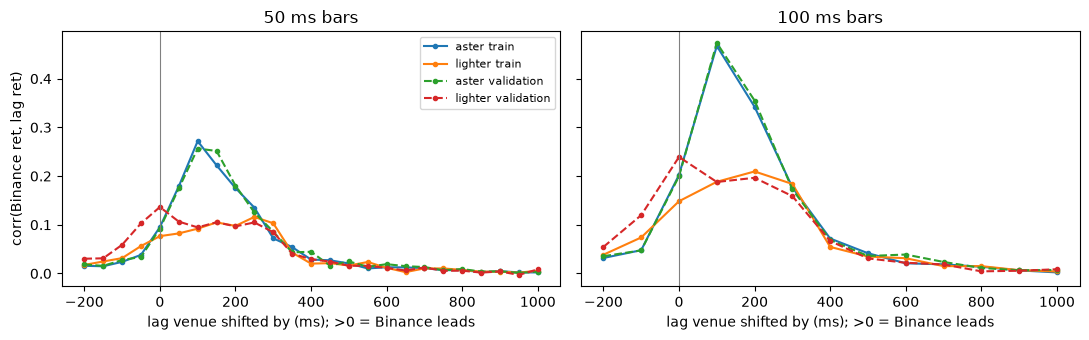

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, bar in zip(axes, BARS_MS):
    for name, style in (("train", "-"), ("validation", "--")):
        for v in LAG_VENUES:
            d = xcorr.filter((pl.col("split") == name) & (pl.col("venue") == v) & (pl.col("bar_ms") == bar))
            ax.plot(d["lag_ms"], d["corr"], style, marker=".", label=f"{v} {name}")
    ax.axvline(0, color="grey", lw=0.8)
    ax.set_title(f"{bar} ms bars"); ax.set_xlabel("lag venue shifted by (ms); >0 = Binance leads")
axes[0].set_ylabel("corr(Binance ret, lag ret)"); axes[0].legend(fontsize=8)
plt.tight_layout()

Aster has a clear peak at about 100–150 ms in both splits. Lighter's curve is flat at about
0.08–0.12 from 0 to 300 ms: it absorbs Binance moves gradually rather than after one fixed
delay. So its peak position is unstable between splits and shouldn't be read as "the" lag.

## 3. Event study: how the lag venue responds to a Binance move

In [7]:
events = {
    (name, x): binance_move_events(venue(name, "binance"), x, WINDOW_NS, COOLDOWN_NS, STALE_NS)
    for name in SPLITS for x in THRESHOLDS_BPS
}
pl.DataFrame([
    {"split": n, "threshold_bps": x, "events": e.height,
     "events_per_hour": e.height / ((tob[n]["t"].max() - tob[n]["t"].min()) / 3.6e12)}
    for (n, x), e in events.items()
])

split,threshold_bps,events,events_per_hour
str,f64,i64,f64
"""train""",2.0,240,17.36251
"""train""",5.0,11,0.795782
"""train""",10.0,1,0.072344
"""validation""",2.0,188,40.801954
"""validation""",5.0,16,3.472507
"""validation""",10.0,2,0.434063


In [8]:
resp = pl.concat([
    responses(e, venue(n, v), HORIZONS_NS, STALE_NS)
    .with_columns(pl.lit(n).alias("split"), pl.lit(x).alias("threshold_bps"), pl.lit(v).alias("venue"))
    for (n, x), e in events.items() for v in LAG_VENUES if e.height
])
resp_summary = resp.group_by("split", "venue", "threshold_bps", "horizon_ns").agg(
    pl.len().alias("n"),
    pl.col("lag_move_bps").null_count().alias("no_quote"),
    pl.col("lead_move_bps").median().alias("lead_bps_p50"),
    pl.col("lag_move_bps").median().alias("lag_bps_p50"),
    pl.col("lag_move_bps").quantile(0.25).alias("lag_bps_p25"),
    pl.col("lag_move_bps").quantile(0.75).alias("lag_bps_p75"),
    pl.col("capture_ratio").median().alias("capture_p50"),
).with_columns((pl.col("horizon_ns") / MS).alias("h_ms")).sort("split", "venue", "threshold_bps", "horizon_ns")
with pl.Config(tbl_rows=200):
    display(resp_summary.filter(pl.col("split") == "train").drop("horizon_ns"))

split,venue,threshold_bps,n,no_quote,lead_bps_p50,lag_bps_p50,lag_bps_p25,lag_bps_p75,capture_p50,h_ms
str,str,f64,u32,u32,f64,f64,f64,f64,f64,f64
"""train""","""aster""",2.0,240,0,2.343958,0.0,0.0,-0.0,0.0,10.0
"""train""","""aster""",2.0,240,0,2.343958,-0.0,-0.0,-0.0,-0.0,25.0
"""train""","""aster""",2.0,240,0,2.343958,0.0,0.0,0.201319,0.0,50.0
"""train""","""aster""",2.0,240,0,2.343958,0.561397,-0.0,1.102532,0.227487,100.0
"""train""","""aster""",2.0,240,0,2.343958,1.767425,1.259903,2.241341,0.70051,250.0
"""train""","""aster""",2.0,240,0,2.343958,2.268721,1.55438,2.877904,0.881227,500.0
"""train""","""aster""",2.0,240,0,2.343958,2.334898,1.654599,3.22058,0.937179,1000.0
"""train""","""aster""",2.0,240,0,2.343958,2.395383,1.70037,3.398149,0.971819,2000.0
"""train""","""aster""",5.0,11,0,5.637393,0.0,-0.0,0.0,0.0,10.0


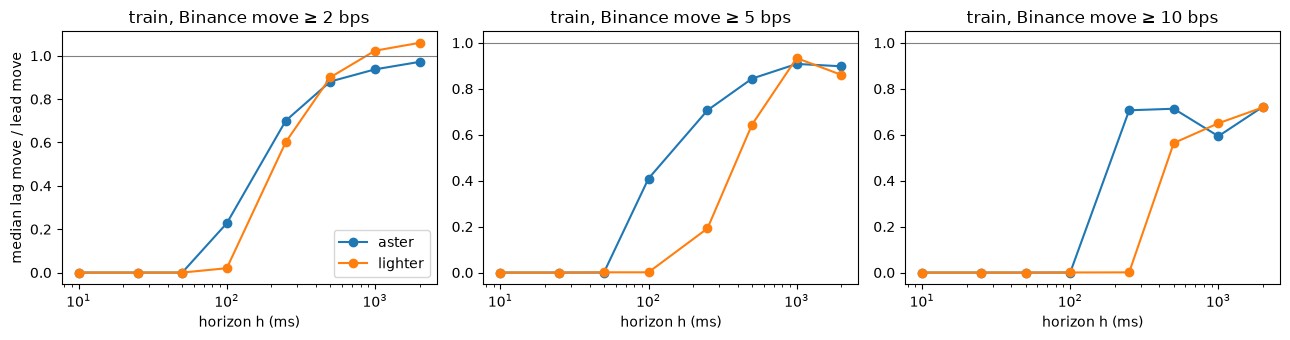

In [9]:
fig, axes = plt.subplots(1, len(THRESHOLDS_BPS), figsize=(13, 3.5), sharey=False)
for ax, x in zip(axes, THRESHOLDS_BPS):
    for v in LAG_VENUES:
        d = resp_summary.filter((pl.col("split") == "train") & (pl.col("venue") == v) & (pl.col("threshold_bps") == x))
        if d.height:
            ax.plot(d["h_ms"], d["capture_p50"], marker="o", label=v)
    ax.set_xscale("log"); ax.axhline(1, color="grey", lw=0.8)
    ax.set_title(f"train, Binance move ≥ {x:g} bps"); ax.set_xlabel("horizon h (ms)")
axes[0].set_ylabel("median lag move / lead move"); axes[0].legend()
plt.tight_layout()

### Catch-up or shared drift?

The capture ratio compares the lag move over $[t_0, t_0+h]$ with Binance's move *before* $t_0$.
If Binance keeps moving after $t_0$, part of the lag "response" is the whole market drifting.
So measure Binance's own signed move after $t_0$ the same way (Binance passed as the "lag" frame).
`catch_up = lag move − Binance post-t0 move` is the part attributable to the lag venue catching up.

In [10]:
binance_post = pl.concat([
    responses(e, venue(n, "binance"), HORIZONS_NS, STALE_NS)
    .select("event_id", "horizon_ns", pl.col("lag_move_bps").alias("binance_post_bps"))
    .with_columns(pl.lit(n).alias("split"), pl.lit(x).alias("threshold_bps"))
    for (n, x), e in events.items() if e.height
])
drift = (
    resp.join(binance_post, on=["split", "threshold_bps", "event_id", "horizon_ns"])
    .group_by("split", "venue", "threshold_bps", "horizon_ns").agg(
        pl.len().alias("n"),
        pl.col("lead_move_bps").mean().alias("lead_mean"),
        pl.col("binance_post_bps").mean().alias("binance_post_mean"),
        pl.col("lag_move_bps").mean().alias("lag_mean"),
        (pl.col("lag_move_bps") - pl.col("binance_post_bps")).mean().alias("catch_up_mean"),
    )
    .with_columns((pl.col("horizon_ns") / MS).alias("h_ms"))
    .filter(pl.col("threshold_bps") < 10.0, pl.col("horizon_ns") >= 100 * MS)
    .sort("threshold_bps", "venue", "split", "horizon_ns")
    .drop("horizon_ns")
)
with pl.Config(tbl_rows=60):
    display(drift)

split,venue,threshold_bps,n,lead_mean,binance_post_mean,lag_mean,catch_up_mean,h_ms
str,str,f64,u32,f64,f64,f64,f64,f64
"""train""","""aster""",2.0,240,2.651526,0.043891,0.670934,0.627042,100.0
"""train""","""aster""",2.0,240,2.651526,0.245636,1.857195,1.611559,250.0
"""train""","""aster""",2.0,240,2.651526,0.327324,2.351993,2.024669,500.0
"""train""","""aster""",2.0,240,2.651526,0.34143,2.551714,2.210284,1000.0
"""train""","""aster""",2.0,240,2.651526,0.444821,2.595088,2.150267,2000.0
"""validation""","""aster""",2.0,188,2.592156,0.052543,0.764309,0.711766,100.0
"""validation""","""aster""",2.0,188,2.592156,0.295984,1.770769,1.474785,250.0
"""validation""","""aster""",2.0,188,2.592156,0.282036,2.279006,1.996971,500.0
"""validation""","""aster""",2.0,188,2.592156,0.308733,2.439512,2.130779,1000.0


In [11]:
first = pl.concat([
    first_lag_move(e, venue(n, v), 2_000 * MS, STALE_NS)
    .with_columns(pl.lit(n).alias("split"), pl.lit(x).alias("threshold_bps"), pl.lit(v).alias("venue"))
    for (n, x), e in events.items() for v in LAG_VENUES if e.height
])
first.group_by("split", "venue", "threshold_bps").agg(
    pl.len().alias("n"),
    pl.col("delay_ns").is_null().sum().alias("no_move_2s"),
    (pl.col("delay_ns").median() / MS).alias("delay_ms_p50"),
    (pl.col("delay_ns").quantile(0.9) / MS).alias("delay_ms_p90"),
    pl.col("same_direction").mean().alias("same_direction_share"),
).sort("split", "venue", "threshold_bps")

split,venue,threshold_bps,n,no_move_2s,delay_ms_p50,delay_ms_p90,same_direction_share
str,str,f64,u32,u32,f64,f64,f64
"""train""","""aster""",2.0,240,0,76.357982,130.914371,0.983333
"""train""","""aster""",5.0,11,0,49.415799,96.624358,0.909091
"""train""","""aster""",10.0,1,0,116.237975,116.237975,1.0
"""train""","""lighter""",2.0,240,0,51.007838,234.143319,0.979167
"""train""","""lighter""",5.0,11,0,47.779364,124.296583,1.0
…,…,…,…,…,…,…,…
"""validation""","""aster""",5.0,16,0,60.575681,98.86551,1.0
"""validation""","""aster""",10.0,2,0,67.193528,99.528161,1.0
"""validation""","""lighter""",2.0,188,1,42.419593,176.541033,0.967914


## 4. Tradability: taker round trip on the lag venue

Up move: buy the lag **ask** at $t_0+L$ and sell the lag **bid** at $t_0+L+h$. Down move: the
reverse. `gross_bps` includes crossing the spread twice; `net_bps = gross_bps − 2·fee`.

In [12]:
edges = pl.concat([
    round_trip_edge(e, venue(n, v), lat, HORIZONS_NS, fee, STALE_NS)
    .with_columns(pl.lit(n).alias("split"), pl.lit(x).alias("threshold_bps"), pl.lit(v).alias("venue"))
    for (n, x), e in events.items() for v in LAG_VENUES if e.height
    for lat in LATENCIES_NS for fee in FEES_BPS
])
grid = edges.group_by("split", "venue", "threshold_bps", "latency_ns", "horizon_ns", "fee_bps").agg(
    pl.col("net_bps").is_not_null().sum().alias("n"),
    pl.col("gross_bps").mean().alias("gross_mean"),
    pl.col("net_bps").mean().alias("net_mean"),
    pl.col("net_bps").median().alias("net_p50"),
    (pl.col("net_bps") > 0).mean().alias("hit_rate"),
).with_columns((pl.col("latency_ns") / MS).alias("L_ms"), (pl.col("horizon_ns") / MS).alias("h_ms"))

with pl.Config(tbl_rows=60):
    display(
        grid.filter((pl.col("split") == "train") & (pl.col("fee_bps") == 5.0) & (pl.col("latency_ns") == 50 * MS))
        .select("venue", "threshold_bps", "h_ms", "n", "gross_mean", "net_mean", "net_p50", "hit_rate")
        .sort("venue", "threshold_bps", "h_ms")
    )

venue,threshold_bps,h_ms,n,gross_mean,net_mean,net_p50,hit_rate
str,f64,f64,u32,f64,f64,f64,f64
"""aster""",2.0,10.0,240,-0.295672,-10.295672,-10.011846,0.0
"""aster""",2.0,25.0,240,-0.22665,-10.22665,-10.011843,0.0
"""aster""",2.0,50.0,240,-0.033726,-10.033726,-10.011831,0.0
"""aster""",2.0,100.0,240,0.370106,-9.629894,-9.774987,0.0
"""aster""",2.0,250.0,240,1.351972,-8.648028,-8.687063,0.0
"""aster""",2.0,500.0,240,1.888097,-8.111903,-8.229989,0.0
"""aster""",2.0,1000.0,240,2.120538,-7.879462,-7.959385,0.0
"""aster""",2.0,2000.0,240,2.171468,-7.828532,-7.918918,0.004167
"""aster""",5.0,10.0,11,-0.878693,-10.878693,-10.768594,0.0


### Choose one cell on train and report it on validation

Selection rule, fixed before looking at validation: for each lag venue, take the
(threshold, horizon) with the highest train `net_mean` at fee 5 bps and $L$ = 50 ms, among cells
with at least 10 train events. Fee is a constant shift, so the same cell maximises gross edge.

In [13]:
MIN_EVENTS = 10
chosen = (
    grid.filter((pl.col("split") == "train") & (pl.col("fee_bps") == 5.0)
                & (pl.col("latency_ns") == 50 * MS) & (pl.col("n") >= MIN_EVENTS))
    .sort("net_mean", descending=True).group_by("venue").first()
    .select("venue", "threshold_bps", "horizon_ns")
)
report = grid.join(chosen, on=["venue", "threshold_bps", "horizon_ns"]).filter(pl.col("latency_ns") == 50 * MS)
report.select("venue", "threshold_bps", "h_ms", "split", "fee_bps", "n", "gross_mean", "net_mean", "net_p50", "hit_rate") \
      .sort("venue", "split", "fee_bps")

venue,threshold_bps,h_ms,split,fee_bps,n,gross_mean,net_mean,net_p50,hit_rate
str,f64,f64,str,f64,u32,f64,f64,f64,f64
"""aster""",5.0,2000.0,"""train""",0.0,11,4.290922,4.290922,3.133499,1.0
"""aster""",5.0,2000.0,"""train""",2.5,11,4.290922,-0.709078,-1.866501,0.454545
"""aster""",5.0,2000.0,"""train""",5.0,11,4.290922,-5.709078,-6.866501,0.090909
"""aster""",5.0,2000.0,"""validation""",0.0,16,3.713299,3.713299,4.182934,0.875
"""aster""",5.0,2000.0,"""validation""",2.5,16,3.713299,-1.286701,-0.817066,0.3125
…,…,…,…,…,…,…,…,…,…
"""lighter""",5.0,2000.0,"""train""",2.5,11,5.404301,0.404301,0.025672,0.545455
"""lighter""",5.0,2000.0,"""train""",5.0,11,5.404301,-4.595699,-4.974328,0.181818
"""lighter""",5.0,2000.0,"""validation""",0.0,16,4.892921,4.892921,5.452579,0.9375


In [14]:
# Latency sensitivity of the chosen cells (gross edge; subtract 2·fee for net).
grid.join(chosen, on=["venue", "threshold_bps", "horizon_ns"]).filter(pl.col("fee_bps") == 0.0) \
    .select("venue", "split", "L_ms", "n", "gross_mean").sort("venue", "split", "L_ms")

venue,split,L_ms,n,gross_mean
str,str,f64,u32,f64
"""aster""","""train""",0.0,11,5.378488
"""aster""","""train""",25.0,11,4.911872
"""aster""","""train""",50.0,11,4.290922
"""aster""","""train""",100.0,11,3.171838
"""aster""","""validation""",0.0,16,4.595217
…,…,…,…,…
"""lighter""","""train""",100.0,11,4.969815
"""lighter""","""validation""",0.0,16,4.729517
"""lighter""","""validation""",25.0,16,5.077088


### Our account tiers

The fee grid above uses placeholder fees. The accounts in use (checked 2026-10-01) are:

- **Aster base tier:** 0 bps maker, **4 bps taker**, so a taker round trip costs 8 bps.
- **Lighter Standard:** 0 bps maker, **0 bps taker**, but taker orders are delayed **300 ms** by
  the venue. With an assumed 50 ms network latency, the effective taker $L$ is 350 ms.

Each venue is evaluated at its own fee and effective latency, using the same events. These cells
were chosen from the venue docs, not by searching the grid, so there is no selection on
validation.

In [15]:
ACCOUNT_TIERS = {  # venue: (taker fee bps, effective taker latency ns)
    "aster": (4.0, 50 * MS),
    "lighter": (0.0, 350 * MS),
}
tier_edges = pl.concat([
    round_trip_edge(e, venue(n, v), lat, HORIZONS_NS, fee, STALE_NS)
    .with_columns(pl.lit(n).alias("split"), pl.lit(x).alias("threshold_bps"), pl.lit(v).alias("venue"))
    for (n, x), e in events.items() if e.height and x < 10.0
    for v, (fee, lat) in ACCOUNT_TIERS.items()
])
tier_grid = (
    tier_edges.filter(pl.col("horizon_ns") >= 250 * MS)
    .group_by("venue", "threshold_bps", "horizon_ns", "split").agg(
        pl.col("net_bps").is_not_null().sum().alias("n"),
        pl.col("gross_bps").mean().alias("gross_mean"),
        pl.col("net_bps").mean().alias("net_mean"),
        (pl.col("net_bps") > 0).mean().alias("hit_rate"),
    )
    .with_columns((pl.col("horizon_ns") / MS).alias("h_ms"))
    .sort("venue", "threshold_bps", "horizon_ns", "split")
    .drop("horizon_ns")
)
with pl.Config(tbl_rows=40):
    display(tier_grid)

venue,threshold_bps,split,n,gross_mean,net_mean,hit_rate,h_ms
str,f64,str,u32,f64,f64,f64,f64
"""aster""",2.0,"""train""",240,1.351972,-6.648028,0.004167,250.0
"""aster""",2.0,"""validation""",188,1.240692,-6.759308,0.005319,250.0
"""aster""",2.0,"""train""",240,1.888097,-6.111903,0.0,500.0
"""aster""",2.0,"""validation""",188,1.683118,-6.316882,0.010638,500.0
"""aster""",2.0,"""train""",240,2.120538,-5.879462,0.008333,1000.0
"""aster""",2.0,"""validation""",188,1.857074,-6.142926,0.005319,1000.0
"""aster""",2.0,"""train""",240,2.171468,-5.828532,0.008333,2000.0
"""aster""",2.0,"""validation""",188,1.991935,-6.008065,0.021277,2000.0
"""aster""",5.0,"""train""",11,2.654893,-5.345107,0.090909,250.0


In [16]:
# Sanity check: recompute a few edges by hand from raw as-of rows.
sample = edges.filter((pl.col("split") == "train") & (pl.col("venue") == "lighter") & (pl.col("threshold_bps") == 2.0)
                      & (pl.col("latency_ns") == 50 * MS) & (pl.col("horizon_ns") == 500 * MS) & (pl.col("fee_bps") == 5.0)
                      ).drop_nulls("net_bps").head(3)
ev = events[("train", 2.0)]
lag_q = venue("train", "lighter").filter(pl.col("mid").is_not_null())
for row in sample.iter_rows(named=True):
    e = ev.filter(pl.col("event_id") == row["event_id"]).row(0, named=True)
    t_in, t_out = e["t0"] + 50 * MS, e["t0"] + 550 * MS
    q_in = lag_q.filter(pl.col("t") <= t_in).tail(1).row(0, named=True)
    q_out = lag_q.filter(pl.col("t") <= t_out).tail(1).row(0, named=True)
    entry, exit_ = (q_in["ask"], q_out["bid"]) if e["direction"] > 0 else (q_in["bid"], q_out["ask"])
    manual = (exit_ / entry - 1) * 1e4 * e["direction"] - 10.0
    assert abs(manual - row["net_bps"]) < 1e-9, (manual, row["net_bps"])
print("hand-computed edges match")

hand-computed edges match


## 5. Interpretation

See `experiments/reports/2026-10-01-lead-lag.md` for the written result. Read this notebook's
numbers with these limits:

- **One capture** (about 14 h train, 5 h validation). Events at the larger thresholds are few.
- **Latency is assumed.** Fees for our tiers are from the venue docs (section 4); the 50 ms
  network latency is not measured.
- **Both legs pay taker prices.** Maker entry, queue position and partial fills are not
  modelled.
- **Lead resolution ≈ 100 ms**, set by the Binance snapshot cadence.
- **Open Binance book-quality issue** (section 1): the book mid moves far less often than trade
  prices. Book-based event times may be late.